<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/kidney_disease_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kidney disease deep learning

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)

In [2]:
df = pd.read_csv("kidney_disease.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [4]:
df.isnull().sum()

,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


In [5]:
for index,i in enumerate(df.columns):
  if index in [16,17,18]:
    df[i] = df[i].replace('\t?',np.nan).astype(float)
    df[i].fillna(df[i].mean(),inplace=True)
  elif index in [6,7,8,9,19,20,21,22,23,24,25]:
    df[i].fillna(df[i].mode()[0],inplace=True)
  else:
    df[i].fillna(df[i].mean(),inplace=True)

/tmp/ipykernel_2917/3069882625.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(),inplace=True)
/tmp/ipykernel_2917/3069882625.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [6]:
le = LabelEncoder()
for i in [6,7,8,9,19,20,21,22,23,24,25]:
  df[df.columns[i]] = le.fit_transform(df[df.columns[i]])

In [7]:
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.000000,36.0,1.2,137.528754,4.627244,15.4,44.0,7800.0,5.200000,1,4,1,0,0,0,0
1,1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,148.036517,18.0,0.8,137.528754,4.627244,11.3,38.0,6000.0,4.707435,0,3,1,0,0,0,0
2,2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.000000,53.0,1.8,137.528754,4.627244,9.6,31.0,7500.0,4.707435,0,4,1,1,0,1,0
3,3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.000000,56.0,3.8,111.000000,2.500000,11.2,32.0,6700.0,3.900000,1,3,1,1,1,1,0
4,4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.000000,26.0,1.4,137.528754,4.627244,11.6,35.0,7300.0,4.600000,0,3,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,1,1,0,0,140.000000,49.0,0.5,150.000000,4.900000,15.7,47.0,6700.0,4.900000,0,3,1,0,0,0,1
396,396,42.0,70.0,1.025,0.0,0.0,1,1,0,0,75.000000,31.0,1.2,141.000000,3.500000,16.5,54.0,7800.0,6.200000,0,3,1,0,0,0,1
397,397,12.0,80.0,1.020,0.0,0.0,1,1,0,0,100.000000,26.0,0.6,137.000000,4.400000,15.8,49.0,6600.0,5.400000,0,3,1,0,0,0,1
398,398,17.0,60.0,1.025,0.0,0.0,1,1,0,0,114.000000,50.0,1.0,135.000000,4.900000,14.2,51.0,7200.0,5.900000,0,3,1,0,0,0,1


In [8]:
df.describe()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,0.882500,0.810000,0.105000,0.055000,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435,0.367500,3.300000,1.080000,0.205000,0.190000,0.150000,0.375000
std,115.614301,16.974966,13.476298,0.005369,1.272318,1.029487,0.322418,0.392792,0.306937,0.228266,74.782634,49.285887,5.617490,9.204273,2.819783,2.716171,8.151081,2523.219976,0.840314,0.482728,0.579517,0.289499,0.404207,0.392792,0.357519,0.484729
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.750000,42.000000,70.000000,1.015000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.875000,34.000000,6975.000000,4.500000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,199.500000,54.000000,78.234536,1.017408,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,126.000000,44.000000,1.400000,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,299.250000,64.000000,80.000000,1.020000,2.000000,0.450142,1.000000,1.000000,0.000000,0.000000,150.000000,61.750000,3.072454,141.000000,4.800000,14.625000,44.000000,9400.000000,5.100000,1.000000,4.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000,1.000000,4.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.shape

(400, 26)

In [10]:
df.groupby('classification').mean()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
classification,,,,,,,,,,,,,,,,,,,,,,,,,
0,124.5,54.443468,79.498763,1.014505,1.606780,0.711225,0.812,0.696,0.168,0.088,171.257551,71.610938,4.350478,135.091431,4.795045,10.993264,34.533046,8806.824490,4.323288,0.588,3.48,1.128,0.328,0.304,0.24
1,324.5,46.549889,71.419588,1.022247,0.033898,0.015005,1.000,1.000,0.000,0.000,109.334794,33.783696,0.942415,141.590958,4.347575,15.081724,46.136920,7738.285714,5.347680,0.000,3.00,1.000,0.000,0.000,0.00


In [11]:
X = df.drop(columns=['classification','id'],axis=1)
Y = df['classification']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.2)

In [12]:
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [15]:
model = keras.Sequential([keras.layers.Flatten(input_shape=(24,)),
                          keras.layers.Dense(12,activation='relu'),
                          keras.layers.Dense(3,activation='sigmoid')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
history = model.fit(X_train,Y_train,validation_split=0.1,epochs=10)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4097 - loss: 1.2082 - val_accuracy: 0.6250 - val_loss: 1.0099
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5417 - loss: 1.0721 - val_accuracy: 0.6875 - val_loss: 0.8752
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6562 - loss: 0.9517 - val_accuracy: 0.7500 - val_loss: 0.7580
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7222 - loss: 0.8476 - val_accuracy: 0.7812 - val_loss: 0.6599
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7674 - loss: 0.7578 - val_accuracy: 0.8125 - val_loss: 0.5782
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8090 - loss: 0.6805 - val_accuracy: 0.8438 - val_loss: 0.5107
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8333 - loss: 0.6148 - val_accuracy: 0.8438 - val_loss: 0.4558
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8576 - loss: 0.5582 - val_accuracy: 0.8750 - val_loss: 0.4103
Epoc

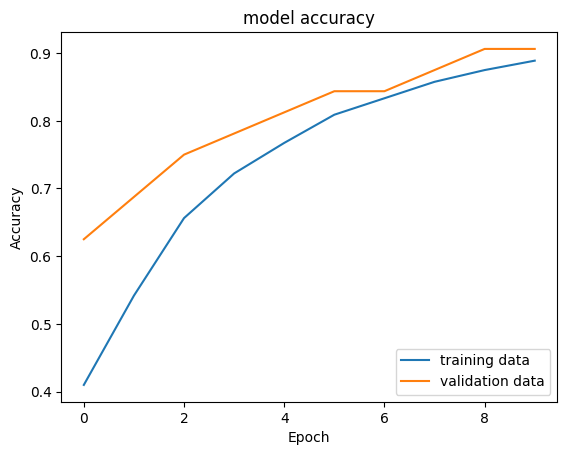

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['training data','validation data'],loc='lower right')

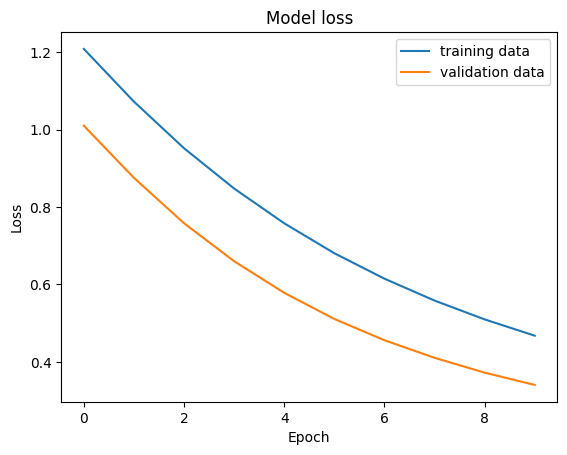

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Model loss')
plt.legend(['training data','validation data'],loc='upper right')

In [20]:
loss, accuracy = model.evaluate(X_test,Y_test,)
print(accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9250 - loss: 0.3895 
0.925000011920929


In [21]:
Y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [22]:
print(Y_pred)

[[0.54355353 0.588922   0.25746164]
 [0.39373285 0.64644885 0.21300884]
 [0.59624994 0.30241677 0.07176238]
 [0.71002    0.5177986  0.40440467]
 [0.89530146 0.35203686 0.3361989 ]
 [0.9174561  0.00808004 0.00744107]
 [0.44071543 0.803055   0.23790327]
 [0.6203047  0.2114213  0.14526336]
 [0.46973    0.7346537  0.289692  ]
 [0.91114175 0.5072826  0.30857813]
 [0.8885471  0.2432313  0.09799639]
 [0.4609335  0.7993533  0.2246665 ]
 [0.9902613  0.12220491 0.17917715]
 [0.8483461  0.23525023 0.31267715]
 [0.8961919  0.24075392 0.243098  ]
 [0.4794536  0.46886283 0.33786455]
 [0.44415402 0.7351507  0.3095761 ]
 [0.39958718 0.8705908  0.28757983]
 [0.6171198  0.47333705 0.46498773]
 [0.35527548 0.77943516 0.23892039]
 [0.8104024  0.19029109 0.11669891]
 [0.5126762  0.23844469 0.13884293]
 [0.40244806 0.91420525 0.29802632]
 [0.47357085 0.73197263 0.225096  ]
 [0.4870229  0.7317965  0.5244755 ]
 [0.46110004 0.89322144 0.336224  ]
 [0.20946735 0.28277248 0.04389082]
 [0.7913968  0.33130264 0.68

In [23]:
y_pred_max = [np.argmax(i) for i in Y_pred]
print(y_pred_max)

[np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0)

In [24]:
input_data = [[48.0	70.0	1.005	4.0	0.0	1	0	1	0	117.000000	56.0	3.8,111.000000,2.500000,11.2,32.0,6700.0,3.900000,1,3,1,1,1,1]]
input_num_data = np.asarray(input_data)
input_num_arr_reshaped = input_num_data.reshape(1,-1)
input_num_arr_std = scaler.transform(input_num_arr_reshaped)
prediction = model.predict(input_num_arr_std)
prediction_max = np.argmax(prediction)
print(prediction_max)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3036377508.py, line 1)